In [ ]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/codveda level 2 task 1 2 3/1 iris coddeva.csv')
print(df.shape)
print(df.columns.tolist())
df.head()

(150, 5)
['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

print(" Libraries loaded successfully!")

 Libraries loaded successfully!


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/codveda level 2 task 1 2 3/1 iris coddeva.csv')

print(" Dataset loaded!")
print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")
print(f"\nSpecies distribution:")
print(df['species'].value_counts())
df.head()

 Dataset loaded!
Rows    : 150
Columns : 5

Species distribution:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [ ]:
print("=" * 45)
print("STATISTICAL SUMMARY")
print("=" * 45)
print(df.describe().round(2))

print(f"\nMissing values: {df.isnull().sum().sum()}")
print(" No missing values!")

STATISTICAL SUMMARY
       sepal_length  sepal_width  petal_length  petal_width
count        150.00       150.00        150.00       150.00
mean           5.84         3.05          3.76         1.20
std            0.83         0.43          1.76         0.76
min            4.30         2.00          1.00         0.10
25%            5.10         2.80          1.60         0.30
50%            5.80         3.00          4.35         1.30
75%            6.40         3.30          5.10         1.80
max            7.90         4.40          6.90         2.50

Missing values: 0
 No missing values!


In [ ]:
# Drop species column — clustering unsupervised
X = df.drop('species', axis=1)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(" Features standardized!")
print(f"Features used : {X.columns.tolist()}")
print(f"Scaled mean   : {X_scaled.mean():.4f}")
print(f"Scaled std    : {X_scaled.std():.4f}")

 Features standardized!
Features used : ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
Scaled mean   : -0.0000
Scaled std    : 1.0000


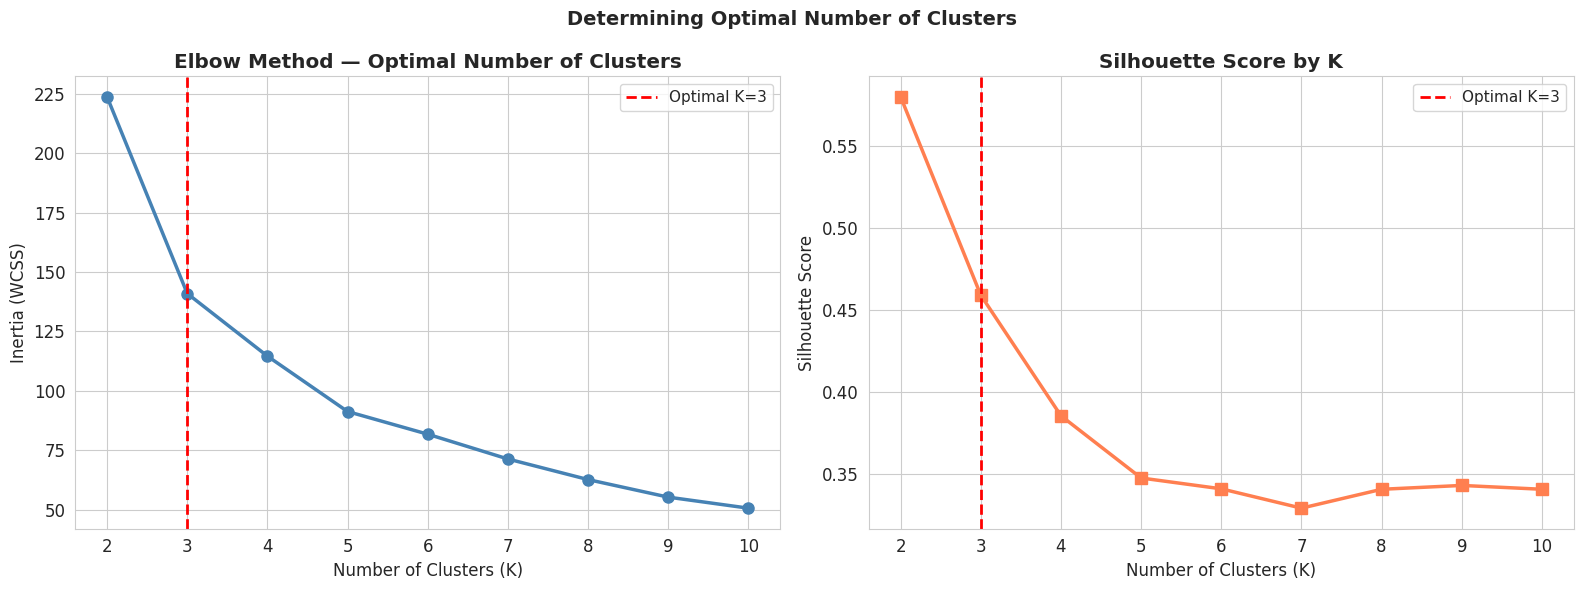

 Saved: elbow_silhouette.png


In [ ]:
inertia = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Elbow curve
axes[0].plot(k_range, inertia,
             marker='o', linewidth=2.5,
             color='steelblue', markersize=8)
axes[0].axvline(x=3, color='red', linewidth=2,
                linestyle='--', label='Optimal K=3')
axes[0].set_title('Elbow Method — Optimal Number of Clusters',
                  fontweight='bold')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia (WCSS)')
axes[0].legend(fontsize=11)

# Silhouette scores
axes[1].plot(k_range, silhouette_scores,
             marker='s', linewidth=2.5,
             color='coral', markersize=8)
axes[1].axvline(x=3, color='red', linewidth=2,
                linestyle='--', label='Optimal K=3')
axes[1].set_title('Silhouette Score by K',
                  fontweight='bold')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].legend(fontsize=11)

plt.suptitle('Determining Optimal Number of Clusters',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('elbow_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Saved: elbow_silhouette.png")

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

print(" K-Means clustering applied!")
print(f"\nCluster distribution:")
print(df['Cluster'].value_counts().sort_index())
print(f"\nSilhouette Score : {silhouette_score(X_scaled, df['Cluster']):.4f}")
print(f"Inertia (WCSS)   : {kmeans.inertia_:.4f}")

 K-Means clustering applied!

Cluster distribution:
Cluster
0    53
1    50
2    47
Name: count, dtype: int64

Silhouette Score : 0.4590
Inertia (WCSS)   : 140.9658


In [ ]:
print("=" * 45)
print("CLUSTER vs ACTUAL SPECIES")
print("=" * 45)
comparison = pd.crosstab(df['Cluster'], df['species'])
print(comparison)

CLUSTER vs ACTUAL SPECIES
species  setosa  versicolor  virginica
Cluster                               
0             0          39         14
1            50           0          0
2             0          11         36


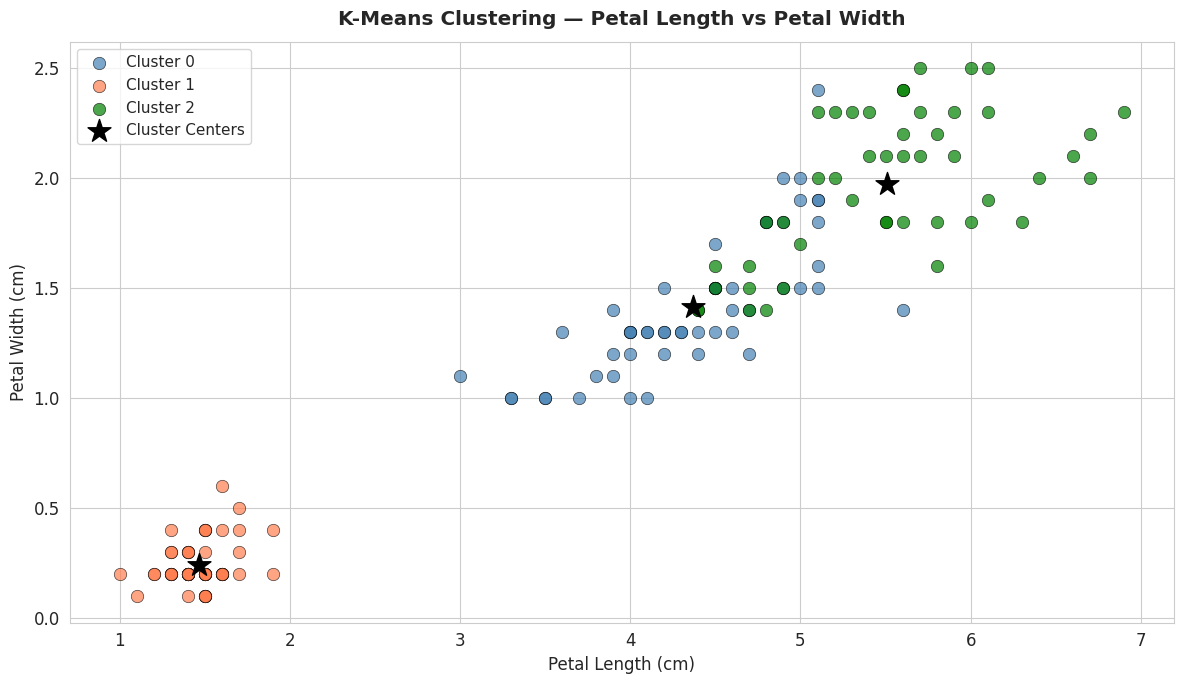

 Saved: scatter_petal.png


In [ ]:
plt.figure(figsize=(12, 7))

colors = {0: 'steelblue', 1: 'coral', 2: 'green'}
cluster_names = {0: 'Cluster 0', 1: 'Cluster 1', 2: 'Cluster 2'}

for cluster in sorted(df['Cluster'].unique()):
    mask = df['Cluster'] == cluster
    plt.scatter(df[mask]['petal_length'],
                df[mask]['petal_width'],
                c=colors[cluster],
                s=80, alpha=0.7,
                edgecolors='black',
                linewidth=0.5,
                label=cluster_names[cluster])

# Plot cluster centers (inverse transform)
centers = scaler.inverse_transform(kmeans.cluster_centers_)
centers_df = pd.DataFrame(centers, columns=X.columns)

plt.scatter(centers_df['petal_length'],
            centers_df['petal_width'],
            c='black', marker='*',
            s=300, zorder=5, label='Cluster Centers')

plt.title('K-Means Clustering — Petal Length vs Petal Width',
          fontweight='bold', pad=12)
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('scatter_petal.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Saved: scatter_petal.png")

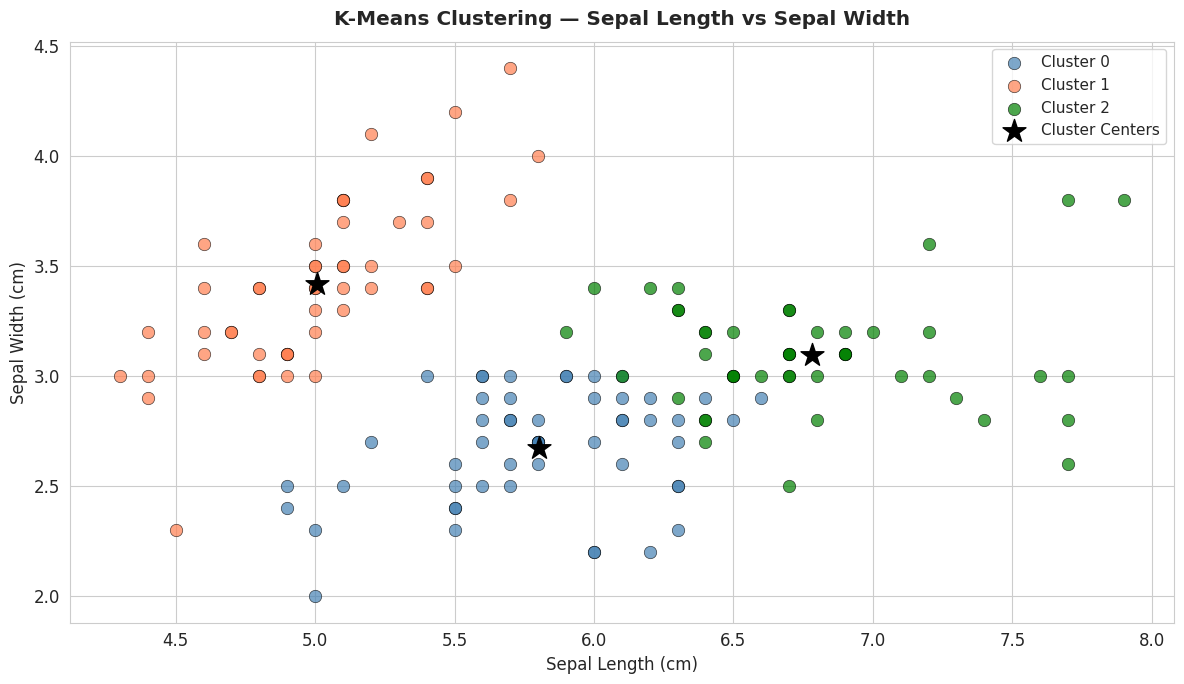

 Saved: scatter2_sepal.png


In [ ]:
plt.figure(figsize=(12, 7))

for cluster in sorted(df['Cluster'].unique()):
    mask = df['Cluster'] == cluster
    plt.scatter(df[mask]['sepal_length'],
                df[mask]['sepal_width'],
                c=colors[cluster],
                s=80, alpha=0.7,
                edgecolors='black',
                linewidth=0.5,
                label=cluster_names[cluster])

plt.scatter(centers_df['sepal_length'],
            centers_df['sepal_width'],
            c='black', marker='*',
            s=300, zorder=5, label='Cluster Centers')

plt.title('K-Means Clustering — Sepal Length vs Sepal Width',
          fontweight='bold', pad=12)
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('scatter_sepal.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Saved: scatter2_sepal.png")

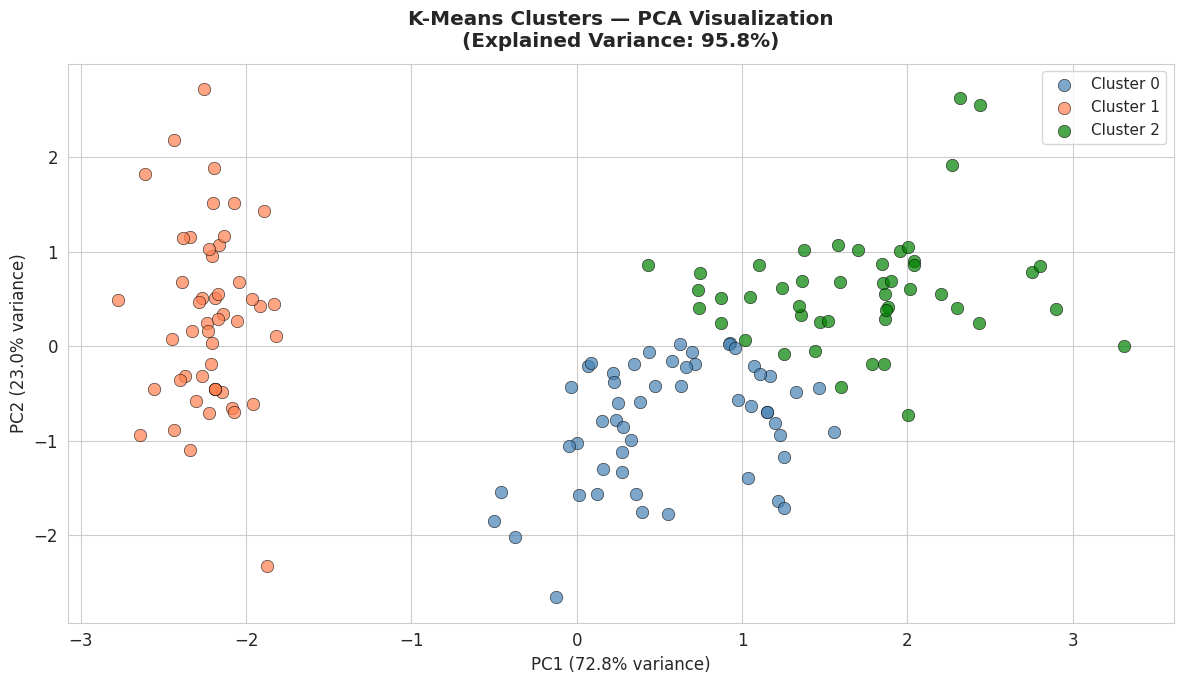

 Saved: pca_clusters.png


In [ ]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(12, 7))

for cluster in sorted(df['Cluster'].unique()):
    mask = df['Cluster'].values == cluster
    plt.scatter(X_pca[mask, 0],
                X_pca[mask, 1],
                c=colors[cluster],
                s=80, alpha=0.7,
                edgecolors='black',
                linewidth=0.5,
                label=cluster_names[cluster])

plt.title(f'K-Means Clusters — PCA Visualization\n'
          f'(Explained Variance: {sum(pca.explained_variance_ratio_)*100:.1f}%)',
          fontweight='bold', pad=12)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('pca_clusters.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Saved: pca_clusters.png")

CLUSTER PROFILES (Mean Values)
         sepal_length  sepal_width  petal_length  petal_width
Cluster                                                      
0                5.80         2.67          4.37         1.41
1                5.01         3.42          1.46         0.24
2                6.78         3.10          5.51         1.97


<Figure size 1200x600 with 0 Axes>

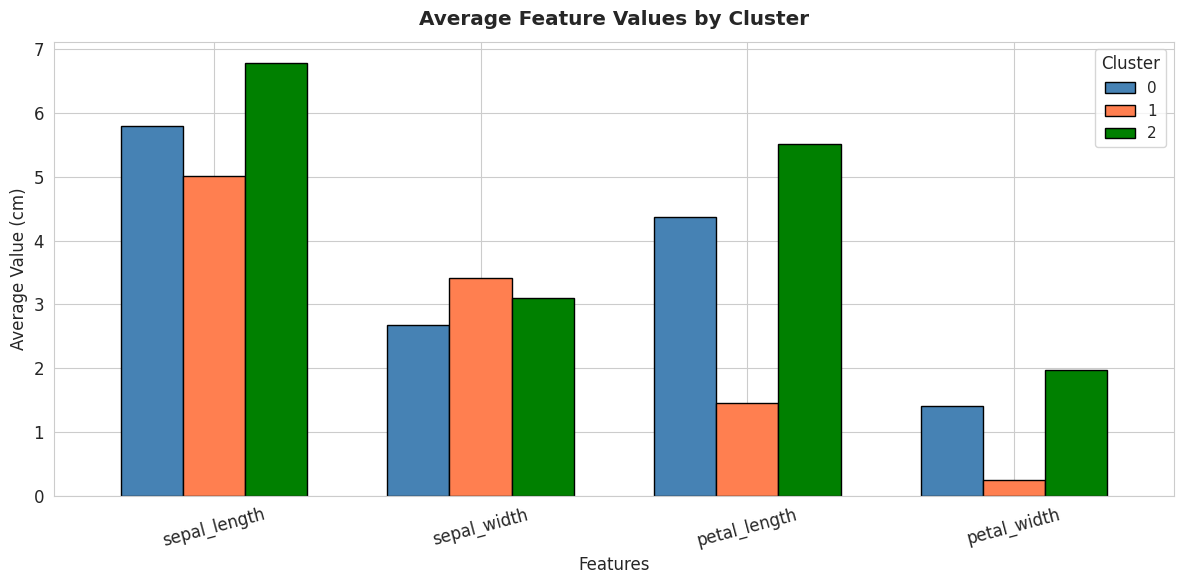

 Saved: cluster_profiles.png


In [ ]:
plt.figure(figsize=(12, 6))

cluster_profile = df.groupby('Cluster')[
    ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
].mean().round(2)

print("=" * 50)
print("CLUSTER PROFILES (Mean Values)")
print("=" * 50)
print(cluster_profile)

cluster_profile.T.plot(kind='bar',
                       color=['steelblue', 'coral', 'green'],
                       edgecolor='black',
                       width=0.7)
plt.title('Average Feature Values by Cluster',
          fontweight='bold', pad=12)
plt.xlabel('Features')
plt.ylabel('Average Value (cm)')
plt.xticks(rotation=15)
plt.legend(title='Cluster', fontsize=11)
plt.tight_layout()
plt.savefig('cluster_profiles.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Saved: cluster_profiles.png")

In [ ]:
print("=" * 55)
print("     FINAL SUMMARY — K-MEANS CLUSTERING")
print("=" * 55)
print(f"\n Dataset         : Iris Flower Dataset (150 rows)")
print(f" Algorithm       : K-Means Clustering")
print(f" Optimal K       : 3 (determined by Elbow Method)")
print(f" Features used   : sepal_length, sepal_width, petal_length, petal_width")

sil = silhouette_score(X_scaled, df['Cluster'])
print(f"\n MODEL RESULTS:")
print(f"   Silhouette Score : {sil:.4f}  (closer to 1 = better)")
print(f"   Inertia (WCSS)   : {kmeans.inertia_:.4f}")
print(f"   PCA Variance     : {sum(pca.explained_variance_ratio_)*100:.1f}%")

print(f"\n Cluster Sizes:")
for c, count in df['Cluster'].value_counts().sort_index().items():
    print(f"   Cluster {c} → {count} flowers")

print(f"\n Key Observations:")
print(f"   - 3 distinct clusters clearly separated")
print(f"   - Petal features show stronger cluster separation than sepal")
print(f"   - K-Means successfully grouped flowers without using species labels")
print(f"   - Silhouette score confirms well-defined clusters")
print("\n K-Means Clustering completed successfully!")

     FINAL SUMMARY — K-MEANS CLUSTERING

 Dataset         : Iris Flower Dataset (150 rows)
 Algorithm       : K-Means Clustering
 Optimal K       : 3 (determined by Elbow Method)
 Features used   : sepal_length, sepal_width, petal_length, petal_width

 MODEL RESULTS:
   Silhouette Score : 0.4590  (closer to 1 = better)
   Inertia (WCSS)   : 140.9658
   PCA Variance     : 95.8%

 Cluster Sizes:
   Cluster 0 → 53 flowers
   Cluster 1 → 50 flowers
   Cluster 2 → 47 flowers

 Key Observations:
   - 3 distinct clusters clearly separated
   - Petal features show stronger cluster separation than sepal
   - K-Means successfully grouped flowers without using species labels
   - Silhouette score confirms well-defined clusters

 K-Means Clustering completed successfully!
